# Lecture 2 Practical — Linear Systems, Iterative Solvers, Matrix Inverse and Eigenvalues

This notebook accompanies Lecture 2 of **Modelling and Simulation**.

The class focused on numerical methods for problems of the form

$
A\mathbf{x}=\mathbf{b},
$

and related matrix computations:

1. Gaussian elimination and back substitution.
2. Pivoting and numerical error.
3. Gauss–Jordan elimination and matrix inverse.

## Practical structure

The practical is designed for approximately **1 hour**.

Each exercise asks you to:

- write or complete a small piece of code;
- run numerical experiments;
- compare methods using residuals, errors or convergence plots;
- modify modular functions or input data and observe what changes.

## Important note for students

Many code cells contain `TODO` sections. Some possible solution lines are included, but commented out.  
To use them, remove the leading comment marker and the `TODO` keyword.

## 0. Imports and global settings

We use:

- `numpy` for arrays and linear algebra;
- `matplotlib` for plotting convergence histories and thermal-node temperatures.

In [3]:

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

DEFAULT_TOL = 1e-10
DEFAULT_MAX_ITER = 200

## 1. Modular test problems

The problems are defined in dictionaries so that you can easily replace the matrix, right-hand side, reference solution, initial guess or physical parameters.

You are encouraged to add your own matrices and thermal networks.

In [4]:

# ============================================================
# Linear systems used throughout the notebook
# ============================================================

linear_problems = {
    "lecture_jacobi_example": {
        "A": np.array([
            [ 4.0, -1.0,  1.0],
            [-4.0,  8.0, -1.0],
            [-2.0,  1.0,  5.0],
        ]),
        "b": np.array([7.0, 21.0, 15.0]),
        "x0": np.array([1.0, 2.0, 2.0]),
        "x_exact": np.array([2.0, 4.0, 3.0]),
        "description": "Lecture example for Jacobi and Gauss-Seidel.",
    },
    "pivoting_example": {
        "A": np.array([
            [1e-8, 1.0],
            [2.0,  1.0],
        ]),
        "b": np.array([1.0, 3.0]),
        "x0": np.array([0.0, 0.0]),
        "x_exact": np.linalg.solve(np.array([[1e-8, 1.0], [2.0, 1.0]]), np.array([1.0, 3.0])),
        "description": "Small pivot example: pivoting should improve numerical behavior.",
    },
    "not_diagonally_dominant": {
        "A": np.array([
            [1.0, 3.0],
            [2.0, 1.0],
        ]),
        "b": np.array([5.0, 5.0]),
        "x0": np.array([0.0, 0.0]),
        "x_exact": np.linalg.solve(np.array([[1.0, 3.0], [2.0, 1.0]]), np.array([5.0, 5.0])),
        "description": "A system that is not strictly diagonally dominant.",
    },
}


def make_hilbert_system(n):
    """
    Return A, b, x_exact for a Hilbert linear system.

    Hilbert matrices are ill-conditioned and are useful for observing
    the difference between residual and actual error.
    """
    A = np.array([[1.0 / (i + j + 1) for j in range(n)] for i in range(n)])
    x_exact = np.ones(n)
    b = A @ x_exact
    return A, b, x_exact


active_name = "lecture_jacobi_example"
problem = linear_problems[active_name]

A = problem["A"]
b = problem["b"]
x0 = problem["x0"]
x_exact = problem["x_exact"]

print(problem["description"])
print("A =")
print(A)
print("b =", b)

Lecture example for Jacobi and Gauss-Seidel.
A =
[[ 4. -1.  1.]
 [-4.  8. -1.]
 [-2.  1.  5.]]
b = [ 7. 21. 15.]


## 2. Helper functions for diagnostics and plotting

These functions are intentionally small. You can reuse them for any solver implemented later.

In [5]:

def residual_norm(A, x, b):
    """Return ||Ax-b||_2."""
    return np.linalg.norm(A @ x - b, ord=2)


def relative_error(x, x_ref):
    """Return ||x-x_ref||_2 / ||x_ref||_2."""
    return np.linalg.norm(x - x_ref, ord=2) / np.linalg.norm(x_ref, ord=2)


def is_strictly_diagonally_dominant(A):
    """
    Check the sufficient convergence condition used in the lecture:
    |a_ii| > sum_{j != i} |a_ij| for every row i.
    """
    diagonal = np.abs(np.diag(A))
    off_diagonal_sum = np.sum(np.abs(A), axis=1) - diagonal
    return np.all(diagonal > off_diagonal_sum)


def plot_history(history, keys=("residual",), title="Convergence history"):
    """
    Plot selected quantities stored in a list of dictionaries.
    """
    if len(history) == 0:
        print("Empty history.")
        return

    for key in keys:
        values = [item[key] for item in history if key in item]
        if len(values) > 0:
            plt.semilogy(values, marker="o", label=key)

    plt.xlabel("Iteration")
    plt.ylabel("Value")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

## Exercise 1 — Gaussian elimination with optional pivoting

**Estimated time: 15 minutes.**

**Objective.** Implement the basic direct solver described in the lecture:

1. transform $(A\mathbf{x}=\mathbf{b})$ into an upper-triangular system;
2. solve by back substitution;
3. optionally use partial pivoting by swapping the current row with the row containing the largest absolute pivot candidate.

### Tasks

1. Complete `back_substitution`.
2. Complete `gaussian_elimination`.
3. Test the solver on `lecture_jacobi_example`.
4. Test the solver on `pivoting_example` with `pivot=False` and `pivot=True`.
5. Compare against `np.linalg.solve`.

### Experiment

Change `1e-8` in the pivoting example to `1e-4`, `1e-12`, and `1e-16`.  
What happens to the residual and relative error when pivoting is disabled? **Pogressive Degradation of the solution**

In [6]:

def back_substitution(U, y, tol=1e-14):
    """
    Solve an upper-triangular system Ux = y.

    Parameters
    ----------
    U : array, shape (n, n)
        Upper-triangular matrix.
    y : array, shape (n,)
        Right-hand side.
    tol : float
        Small pivot threshold.

    Returns
    -------
    x : array, shape (n,)
    """
    U = np.array(U, dtype=float)
    y = np.array(y, dtype=float)
    n = len(y)
    x = np.zeros(n)

    # TODO:
    # Implement back substitution from row n-1 down to row 0.
    for i in range(n - 1, -1, -1):
        if abs(U[i, i]) < tol:
            raise ZeroDivisionError(f"Pivot too small at row {i}: U[{i},{i}] = {U[i, i]}")
        
        x[i] = (y[i] - np.dot(U[i, i + 1:], x[i + 1:])) / U[i, i]
    # 
    print("Solution x =", x)
    return x



def gaussian_elimination(A, b, pivot=False, tol=1e-14):
    """
    Solve Ax = b using Gaussian elimination.

    If pivot=True, use partial pivoting.
    """
    A = np.array(A, dtype=float).copy()
    b = np.array(b, dtype=float).copy()
    n = len(b)

    for k in range(n - 1):
        # TODO:
        # If pivot=True, find the row p >= k where |A[p,k]| is largest.
        for k in range(n - 1):
            if pivot:
                p = np.argmax(np.abs(A[k:, k])) + k
        else:
            p = k
        # Swap rows k and p in both A and b.
        if p != k:
            A[[k, p], :] = A[[p, k], :]
            b[[k, p]] = b[[p, k]]
        #
        # TODO:
        # Check that the pivot is not too small.
        if abs(A[k, k]) < tol:
            raise ZeroDivisionError(f"Pivot too small at row {k}: A[{k},{k}] = {A[k, k]}")
        #
        # TODO:
        # Eliminate entries below the pivot.
        for i in range(k + 1, n):
            m = A[i, k] / A[k, k]
            A[i, k:] -= m * A[k, k:]
            b[i] -= m * b[k]
        #
    return back_substitution(A, b, tol=tol)

In [11]:

# Test Exercise 1 on the active problem.

A = problem["A"]
b = problem["b"]
x_exact = problem["x_exact"]

# TODO:
# Solve with your Gaussian elimination implementation.
#
# TODO 
x_ge = gaussian_elimination(A, b, pivot=True)
# TODO 
print("Gaussian elimination solution:", x_ge)
# TODO 
print("Residual norm:", residual_norm(A, x_ge, b))
# TODO 
print("Relative error:", relative_error(x_ge, x_exact))
# TODO 
print("NumPy solution:", np.linalg.solve(A, b))

Solution x = [1.87804878 2.92682927 2.41463415]
Gaussian elimination solution: [1.87804878 2.92682927 2.41463415]
Residual norm: 8.398889476462625
Relative error: 0.22812736173274348
NumPy solution: [2. 4. 3.]


In [15]:

# Pivoting experiment.

pivot_problem = linear_problems["pivoting_example"]
A_piv = pivot_problem["A"]
b_piv = pivot_problem["b"]
x_ref = np.linalg.solve(A_piv, b_piv)

# TODO:
# Compare no pivoting and pivoting.
x_no_pivot = gaussian_elimination(A_piv, b_piv, pivot=False)
x_pivot    = gaussian_elimination(A_piv, b_piv, pivot=True)

print("\nWithout pivot")
print("Solution:", x_no_pivot)
print("Residual norm:", residual_norm(A_piv, x_no_pivot, b_piv))
print("Relative error:", relative_error(x_no_pivot, x_ref))

print("\nWith partial pivot")
print("Solution:", x_pivot)
print("Residual norm:", residual_norm(A_piv, x_pivot, b_piv))
print("Relative error:", relative_error(x_pivot, x_ref))

print("\nreference")
print("Solution:", x_ref)

Solution x = [1.00000001 0.99999999]
Solution x = [1.00000001 0.99999999]

Without pivot
Solution: [1.00000001 0.99999999]
Residual norm: 4.951861143354108e-11
Relative error: 1.7507473013567986e-11

With partial pivot
Solution: [1.00000001 0.99999999]
Residual norm: 4.951861143354108e-11
Relative error: 1.7507473013567986e-11

reference
Solution: [1.         0.99999999]


## Exercise 2 — Jacobi, Gauss–Seidel and overrelaxation

**Objective.** Implement a single modular iterative solver with three modes:

- `"jacobi"`: use only values from the previous iteration;
- `"gauss_seidel"`: update each component immediately and reuse it within the same iteration;
- `"sor"`: successive overrelaxation with a relaxation factor \(\omega\).

The overrelaxation update can be written as

$$
x_i^{(k+1)} = x_i^{(k)} + \omega \left(\hat{x}_i^{(k+1)} - x_i^{(k)}\right),
$$

where $(\hat{x}_i^{(k+1)})$ is the usual Gauss–Seidel update.

### Tasks

1. Complete `stationary_iteration`.
2. Test Jacobi and Gauss–Seidel on the lecture example.
3. Plot residual histories.


In [22]:

def stationary_iteration(A, b, x0, method="jacobi", omega=1.0,
                         tol=DEFAULT_TOL, max_iter=DEFAULT_MAX_ITER):
    """
    Solve Ax=b using Jacobi, Gauss-Seidel or SOR.

    Parameters
    ----------
    method : {"jacobi", "gauss_seidel", "sor"}
    omega : float
        Relaxation factor. Used only for method="sor".

    Returns
    -------
    x : array
        Approximate solution.
    history : list of dict
        Residual and step norm per iteration.
    """
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    x = np.array(x0, dtype=float).copy()
    n = len(b)
    history = []

    for k in range(max_iter):
        x_old = x.copy()

        # TODO:
        # Implement the three methods.
        #
        # TODO if method == "jacobi":
        #     #
        # TODO elif method in ["gauss_seidel", "sor"]:
        #    #
        # TODO else:
        # TODO     raise ValueError("Unknown method.")


        # Implement the three methods.
        if method == "jacobi":
            x_new = np.zeros(n)
            for i in range(n):
                s = np.dot(A[i, :i], x_old[:i]) + np.dot(A[i, i+1:], x_old[i+1:])
                x_new[i] = (b[i] - s) / A[i, i]
            x = x_new

        elif method in ["gauss_seidel", "sor"]:
            for i in range(n):
                s = np.dot(A[i, :i], x[:i]) + np.dot(A[i, i+1:], x_old[i+1:])
                x_gs = (b[i] - s) / A[i, i]
                if method == "sor":
                    x[i] = (1 - omega) * x_old[i] + omega * x_gs
                else:
                    x[i] = x_gs

        else:
            raise ValueError("Unknown method.")

        res = residual_norm(A, x, b)
        step = np.linalg.norm(x - x_old, ord=2)

        history.append({
            "iteration": k,
            "residual": res,
            "step": step,
            "x": x.copy(),
        })

        # TODO:
        # Stop when residual or step is small.
        if res < tol or step < tol:
            break
        #
        # 
    return x, history

Strictly diagonally dominant? True
Jacobi: [2. 4. 3.] iterations: 23 error: 3.905075353164818e-12
Gauss-Seidel: [2. 4. 3.] iterations: 13 error: 1.1349197043504583e-12
SOR: [2. 4. 3.] iterations: 13 error: 1.1349197043504583e-12


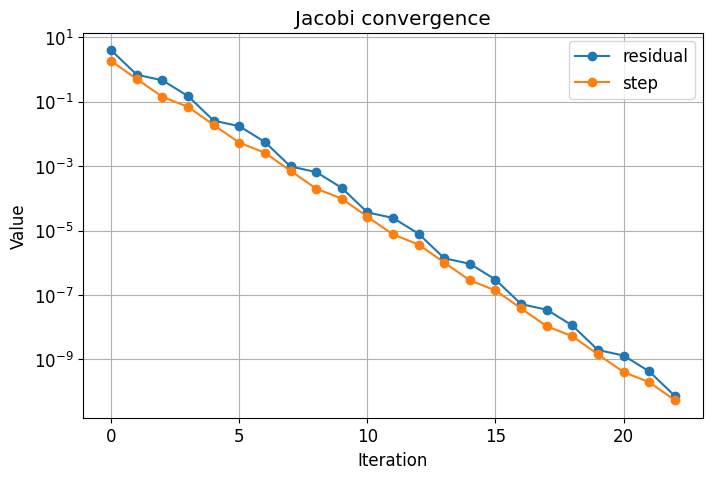

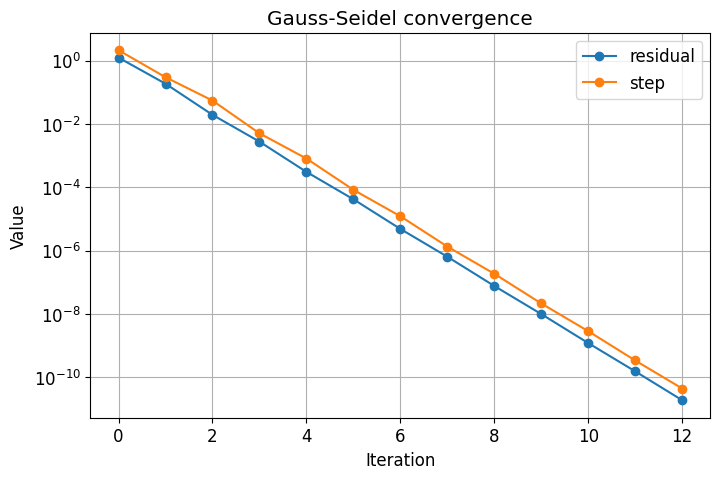

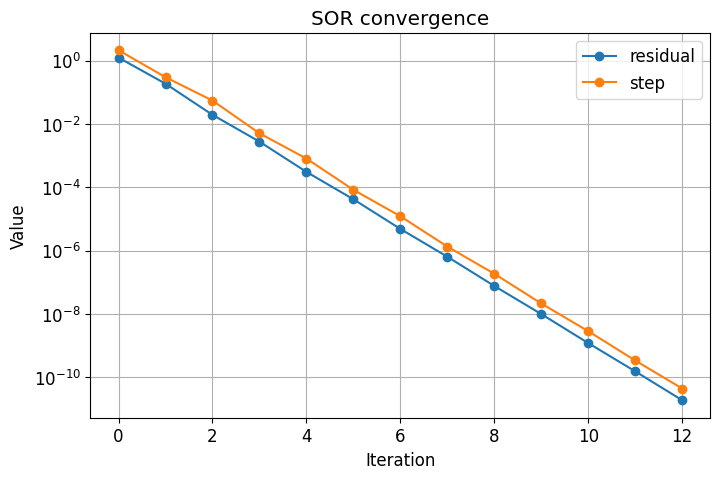

In [33]:

# Test Exercise 3 on the lecture Jacobi/Gauss-Seidel example.

problem = linear_problems["lecture_jacobi_example"]
A = problem["A"]
b = problem["b"]
x0 = problem["x0"]
x_exact = problem["x_exact"]

print("Strictly diagonally dominant?", is_strictly_diagonally_dominant(A))

# TODO:
# Run Jacobi and Gauss-Seidel, then compare iteration counts.
#
# TODO 
x_jac, hist_jac = stationary_iteration(A, b, x0, method="jacobi")
# TODO 
x_gs, hist_gs = stationary_iteration(A, b, x0, method="gauss_seidel")
# TODO 

x_s, hist_s = stationary_iteration(A, b, x0, method="sor", omega=1)

print("Jacobi:", x_jac, "iterations:", len(hist_jac), "error:", relative_error(x_jac, x_exact))
# TODO 
print("Gauss-Seidel:", x_gs, "iterations:", len(hist_gs), "error:", relative_error(x_gs, x_exact))
# TODO 

print("SOR:", x_s, "iterations:", len(hist_s), "error:", relative_error(x_s, x_exact))

plot_history(hist_jac, keys=("residual", "step"), title="Jacobi convergence")
# TODO 
plot_history(hist_gs, keys=("residual", "step"), title="Gauss-Seidel convergence")

plot_history(hist_s, keys=("residual", "step"), title="SOR convergence")

## Final reflection questions

1. For direct solvers, what is the role of pivoting?
**It prevents from dividing by 0 or a small number, it keeps the stabillity**
2. In the iterative methods, how did diagonal dominance affect convergence?
**It guarantees convergence for Jacobi and Gauss-Seidel. Strong dominance = fast convergence**
3. Did Gauss–Seidel converge faster than Jacobi for the lecture example?
Yes
4. Was there an optimal overrelaxation factor $(\omega)$ in your experiment?
**Yes omega = 1 was the best** 
5. Why can the power method converge slowly when the two largest eigenvalues are close?
**Because this method depends on $\frac{\lambda_2}{\lambda_1}$. When the 2 values are close the error decays slowly**
6. In the thermal-node model, which parameter changes reduced the maximum temperature and which reduced the temperature gradient?
